# 🎨 SKU-110K Data Preprocessing

**Project:** Stock Opname Monitoring dengan Deep Learning  
**Author:** Ivan David (B25B8M113)  
**Phase:** Week 2 - Data Preprocessing

---

## 🎯 Tujuan Notebook:
1. Reorganize dataset (train/val/test folders)
2. Resize images ke ukuran standard (640x640)
3. Setup data augmentation
4. Convert annotations dari CSV ke YOLO format
5. Create data.yaml config untuk YOLOv8
6. Validate preprocessing results

## 1. Import Libraries

In [1]:
import os
import shutil
import pandas as pd
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import yaml
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 2. Configuration

In [ ]:
# Paths
BASE_DIR = "./data"  # Changed: No SKU110K subfolder
IMAGES_DIR = os.path.join(BASE_DIR, "images")
ANNOTATIONS_DIR = os.path.join(BASE_DIR, "annotations")

# Output directories for YOLO format
YOLO_DIR = "./data/YOLO"  # Changed path
YOLO_IMAGES_DIR = os.path.join(YOLO_DIR, "images")
YOLO_LABELS_DIR = os.path.join(YOLO_DIR, "labels")

# Preprocessing parameters
TARGET_SIZE = 640  # YOLOv8 default
RESIZE_METHOD = 'letterbox'  # 'letterbox' or 'stretch'

print(f"✓ Configuration set")
print(f"  • Base directory: {BASE_DIR}")
print(f"  • Target size: {TARGET_SIZE}x{TARGET_SIZE}")
print(f"  • Resize method: {RESIZE_METHOD}")

✓ Configuration set
  • Base directory: ./data
  • Target size: 640x640
  • Resize method: letterbox


## 3. Check Dataset Structure

In [18]:
# Check if dataset is organized
ORGANIZED = os.path.exists(os.path.join(IMAGES_DIR, "train"))

if ORGANIZED:
    print("✓ Dataset sudah ter-organize (train/val/test folders)")
    TRAIN_IMG_DIR = os.path.join(IMAGES_DIR, "train")
    VAL_IMG_DIR = os.path.join(IMAGES_DIR, "val")
    TEST_IMG_DIR = os.path.join(IMAGES_DIR, "test")
else:
    print("⚠️  Dataset masih flat structure")
    print("💡 Jalankan: python reorganize_dataset.py")
    print("\nAtau run reorganize di notebook ini...")
    
    response = input("Reorganize sekarang? (y/n): ")
    if response.lower() == 'y':
        # Run reorganize script
        !python reorganize_dataset.py
        ORGANIZED = True
        TRAIN_IMG_DIR = os.path.join(IMAGES_DIR, "train")
        VAL_IMG_DIR = os.path.join(IMAGES_DIR, "val")
        TEST_IMG_DIR = os.path.join(IMAGES_DIR, "test")

⚠️  Dataset masih flat structure
💡 Jalankan: python reorganize_dataset.py

Atau run reorganize di notebook ini...

🔄 REORGANIZE SKU-110K DATASET
📁 Membuat folder train/val/test...
✓ Folder berhasil dibuat

📋 Membaca annotations...
  • Train: 8219 images
  • Val: 588 images
  • Test: 2936 images

📦 Memindahkan train images...
✓ Berhasil memindahkan: 8219 files

📦 Memindahkan val images...
✓ Berhasil memindahkan: 588 files

📦 Memindahkan test images...
✓ Berhasil memindahkan: 2936 files

✅ REORGANIZE COMPLETE!

📊 Summary:
  • Train: 8219 files moved
  • Val: 588 files moved
  • Test: 2936 files moved
  • Total: 11743 files

📁 Struktur baru:

./data/
├── images/
│   ├── train/     (8219 images)
│   ├── val/       (588 images)
│   └── test/      (2936 images)
└── annotations/
    ├── annotations_train.csv
    ├── annotations_val.csv
    └── annotations_test.csv
        

✨ Dataset siap untuk training!

🔍 VALIDASI DATASET

📊 Checking train...
  • Images di folder: 8219
  • Images di annotat


Moving train: 100%|██████████| 8219/8219 [00:20<00:00, 410.14it/s]

Moving val: 100%|██████████| 588/588 [00:00<00:00, 1315.59it/s]

Moving test: 100%|██████████| 2936/2936 [00:02<00:00, 1324.44it/s]


## 4. Load Annotations

In [20]:
# Check dan fix column names jika perlu
if '208' in str(train_df.columns.tolist()):
    print("⚠️ Detected numeric columns - fixing...")
    train_df.columns = ['image_name', 'x1', 'y1', 'x2', 'y2', 'class', 'image_width', 'image_height']
    val_df.columns = ['image_name', 'x1', 'y1', 'x2', 'y2', 'class', 'image_width', 'image_height']
    test_df.columns = ['image_name', 'x1', 'y1', 'x2', 'y2', 'class', 'image_width', 'image_height']
    print("✓ Column names fixed!")

# Verify
print("Columns:", train_df.columns.tolist())
print("\nSample data:")
print(train_df.head(3))

# Jumlah objek per image
objects_per_image = train_df.groupby('image_name').size().reset_index(name='count')

print("\n📊 Statistik Objek per Image:")
print(f"  • Mean: {objects_per_image['count'].mean():.2f}")
print(f"  • Median: {objects_per_image['count'].median():.2f}")
print(f"  • Min: {objects_per_image['count'].min()}")
print(f"  • Max: {objects_per_image['count'].max()}")
print(f"  • Total unique images: {len(objects_per_image)}")

Columns: ['image_name', 'x1', 'y1', 'x2', 'y2', 'class', 'image_width', 'image_height']

Sample data:
    image_name    x1    y1    x2    y2   class  image_width  image_height
0  train_0.jpg   208   537   422   814  object         3024          3024
1  train_0.jpg  1268  1923  1365  2209  object         3024          3024
2  train_0.jpg  1135  2074  1261  2166  object         3024          3024

📊 Statistik Objek per Image:
  • Mean: 147.04
  • Median: 138.00
  • Min: 1
  • Max: 576
  • Total unique images: 8219


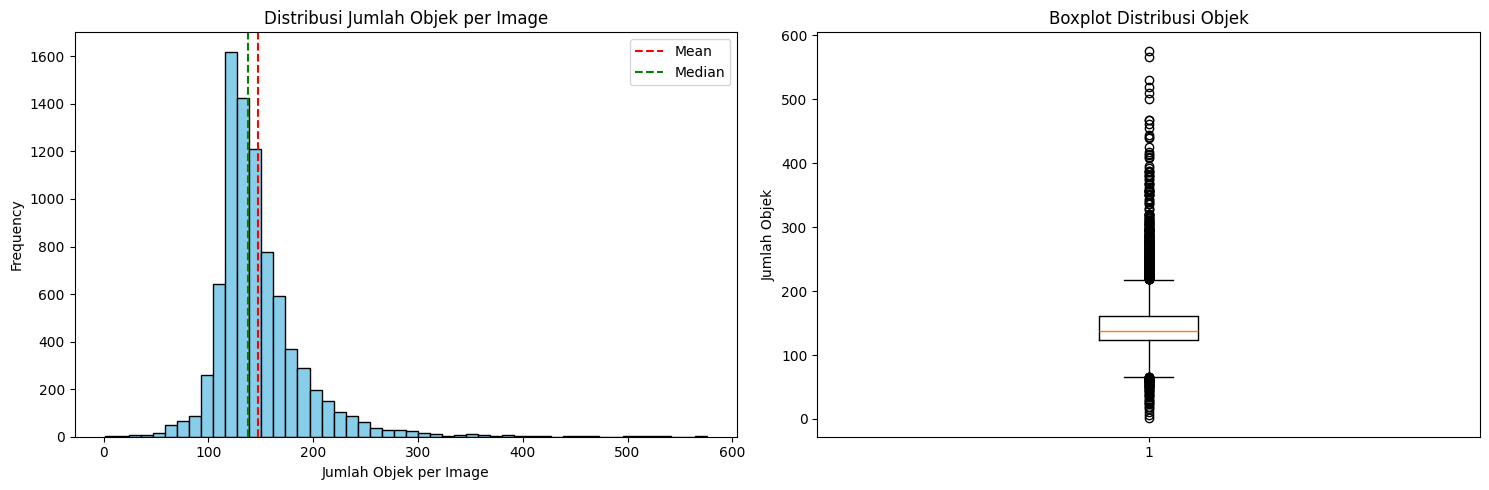

In [21]:
# Visualisasi distribusi
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(objects_per_image['count'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Jumlah Objek per Image')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribusi Jumlah Objek per Image')
axes[0].axvline(objects_per_image['count'].mean(), color='red', linestyle='--', label='Mean')
axes[0].axvline(objects_per_image['count'].median(), color='green', linestyle='--', label='Median')
axes[0].legend()

# Boxplot
axes[1].boxplot(objects_per_image['count'])
axes[1].set_ylabel('Jumlah Objek')
axes[1].set_title('Boxplot Distribusi Objek')

plt.tight_layout()
plt.show()

In [22]:
def load_annotations(split='train'):
    """Load annotations dengan proper column names"""
    ann_file = os.path.join(ANNOTATIONS_DIR, f"annotations_{split}.csv")
    
    if not os.path.exists(ann_file):
        print(f"⚠️ File tidak ditemukan: {ann_file}")
        return None
    
    # Read CSV without header
    df = pd.read_csv(ann_file, header=None)
    
    # Assign column names
    df.columns = ['image_name', 'x1', 'y1', 'x2', 'y2', 'class', 'image_width', 'image_height']
    
    print(f"✓ Loaded {split}: {len(df)} annotations, {df['image_name'].nunique()} images")
    return df

# Load all splits
train_df = load_annotations('train')
val_df = load_annotations('val')
test_df = load_annotations('test')

print(f"\n✓ Total annotations: {len(train_df) + len(val_df) + len(test_df):,}")

✓ Loaded train: 1208482 annotations, 8219 images
✓ Loaded val: 90968 annotations, 588 images
✓ Loaded test: 431546 annotations, 2936 images

✓ Total annotations: 1,730,996


## 5. Convert to YOLO Format

YOLO format requirements:
- Each image has a `.txt` file with same name
- Format: `class x_center y_center width height` (normalized 0-1)
- For SKU-110K: single class (class = 0)

In [23]:
def convert_bbox_to_yolo(bbox, img_width, img_height):
    """
    Convert bbox from (x1, y1, x2, y2) to YOLO format
    YOLO format: class x_center y_center width height (normalized)
    """
    x1, y1, x2, y2 = bbox
    
    # Calculate center, width, height
    x_center = (x1 + x2) / 2.0
    y_center = (y1 + y2) / 2.0
    width = x2 - x1
    height = y2 - y1
    
    # Normalize to 0-1
    x_center /= img_width
    y_center /= img_height
    width /= img_width
    height /= img_height
    
    # Clip to valid range
    x_center = np.clip(x_center, 0, 1)
    y_center = np.clip(y_center, 0, 1)
    width = np.clip(width, 0, 1)
    height = np.clip(height, 0, 1)
    
    return x_center, y_center, width, height

# Test conversion
test_bbox = [100, 200, 150, 250]
test_img_size = (1000, 800)
yolo_bbox = convert_bbox_to_yolo(test_bbox, test_img_size[0], test_img_size[1])
print(f"✓ Conversion test:")
print(f"  Input: {test_bbox}")
print(f"  Output: {yolo_bbox}")

✓ Conversion test:
  Input: [100, 200, 150, 250]
  Output: (0.125, 0.28125, 0.05, 0.0625)


In [24]:
def create_yolo_labels(df, split, output_dir):
    """
    Create YOLO format label files from dataframe
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # Group by image
    grouped = df.groupby('image_name')
    
    print(f"\n📝 Creating YOLO labels for {split}...")
    
    for image_name, group in tqdm(grouped, desc=f"Processing {split}"):
        # Output label file
        label_name = image_name.replace('.jpg', '.txt')
        label_path = os.path.join(output_dir, label_name)
        
        # Convert all bboxes for this image
        yolo_lines = []
        for _, row in group.iterrows():
            bbox = [row['x1'], row['y1'], row['x2'], row['y2']]
            img_w = row['image_width']
            img_h = row['image_height']
            
            x_c, y_c, w, h = convert_bbox_to_yolo(bbox, img_w, img_h)
            
            # YOLO format: class x_center y_center width height
            # Class 0 for all objects (single class detection)
            yolo_line = f"0 {x_c:.6f} {y_c:.6f} {w:.6f} {h:.6f}"
            yolo_lines.append(yolo_line)
        
        # Write to file
        with open(label_path, 'w') as f:
            f.write('\n'.join(yolo_lines))
    
    print(f"✓ Created {len(grouped)} label files for {split}")
    return len(grouped)

In [25]:
# Create YOLO label directories
train_labels_dir = os.path.join(YOLO_LABELS_DIR, "train")
val_labels_dir = os.path.join(YOLO_LABELS_DIR, "val")
test_labels_dir = os.path.join(YOLO_LABELS_DIR, "test")

# Convert annotations to YOLO format
train_count = create_yolo_labels(train_df, 'train', train_labels_dir)
val_count = create_yolo_labels(val_df, 'val', val_labels_dir)
test_count = create_yolo_labels(test_df, 'test', test_labels_dir)

print(f"\n✅ YOLO labels created:")
print(f"  • Train: {train_count} files")
print(f"  • Val: {val_count} files")
print(f"  • Test: {test_count} files")


📝 Creating YOLO labels for train...


Processing train: 100%|██████████| 8219/8219 [02:25<00:00, 56.65it/s]


✓ Created 8219 label files for train

📝 Creating YOLO labels for val...


Processing val: 100%|██████████| 588/588 [00:12<00:00, 46.95it/s]


✓ Created 588 label files for val

📝 Creating YOLO labels for test...


Processing test: 100%|██████████| 2936/2936 [01:10<00:00, 41.74it/s]

✓ Created 2936 label files for test

✅ YOLO labels created:
  • Train: 8219 files
  • Val: 588 files
  • Test: 2936 files


## 6. Copy/Link Images to YOLO Structure

In [26]:
def setup_yolo_images(split):
    """
    Create symbolic links or copy images to YOLO directory structure
    """
    src_dir = os.path.join(IMAGES_DIR, split)
    dst_dir = os.path.join(YOLO_IMAGES_DIR, split)
    
    os.makedirs(dst_dir, exist_ok=True)
    
    # On Windows, copy files. On Unix, can use symlinks
    import platform
    
    if platform.system() == 'Windows':
        print(f"📁 Copying {split} images to YOLO structure...")
        # For large datasets, consider just keeping reference to original location
        print(f"   Note: Using original location at {src_dir}")
        print(f"   Update data.yaml to point to original images")
    else:
        print(f"🔗 Creating symlinks for {split} images...")
        if os.path.exists(dst_dir):
            shutil.rmtree(dst_dir)
        os.symlink(src_dir, dst_dir, target_is_directory=True)
    
    print(f"✓ {split} images ready")

# Setup image directories
if ORGANIZED:
    setup_yolo_images('train')
    setup_yolo_images('val')
    setup_yolo_images('test')
else:
    print("⚠️  Please reorganize dataset first!")

📁 Copying train images to YOLO structure...
   Note: Using original location at ./data\images\train
   Update data.yaml to point to original images
✓ train images ready
📁 Copying val images to YOLO structure...
   Note: Using original location at ./data\images\val
   Update data.yaml to point to original images
✓ val images ready
📁 Copying test images to YOLO structure...
   Note: Using original location at ./data\images\test
   Update data.yaml to point to original images
✓ test images ready


## 7. Create data.yaml Config File

In [27]:
def create_data_yaml():
    """
    Create data.yaml configuration file for YOLOv8
    """
    # Get absolute paths
    import os
    base_path = os.path.abspath(BASE_DIR)
    
    data_config = {
        'path': base_path,  # Root directory (data/)
        'train': 'images/train',  # Relative to path
        'val': 'images/val',
        'test': 'images/test',
        
        # Classes
        'nc': 1,  # Number of classes
        'names': ['object']  # Class names
    }
    
    # Save to file
    yaml_path = os.path.join(BASE_DIR, 'data.yaml')
    
    with open(yaml_path, 'w') as f:
        yaml.dump(data_config, f, default_flow_style=False, sort_keys=False)
    
    print(f"✓ Created data.yaml at: {yaml_path}")
    print(f"\n📄 Contents:")
    print(yaml.dump(data_config, default_flow_style=False, sort_keys=False))
    
    return yaml_path

yaml_path = create_data_yaml()

✓ Created data.yaml at: ./data\data.yaml

📄 Contents:
path: d:\files\data
train: images/train
val: images/val
test: images/test
nc: 1
names:
- object



## 8. Validate YOLO Format

In [28]:
def validate_yolo_labels(label_dir, num_samples=5):
    """
    Validate YOLO label format
    """
    label_files = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
    
    print(f"\n🔍 Validating labels in {label_dir}...")
    print(f"Total label files: {len(label_files)}")
    
    # Check random samples
    samples = np.random.choice(label_files, min(num_samples, len(label_files)), replace=False)
    
    for label_file in samples:
        label_path = os.path.join(label_dir, label_file)
        
        with open(label_path, 'r') as f:
            lines = f.readlines()
        
        print(f"\n  {label_file}: {len(lines)} objects")
        
        # Validate first line
        if lines:
            parts = lines[0].strip().split()
            if len(parts) == 5:
                cls, x, y, w, h = parts
                print(f"    First object: class={cls}, x={x[:6]}, y={y[:6]}, w={w[:6]}, h={h[:6]}")
                
                # Check values are in valid range
                x, y, w, h = float(x), float(y), float(w), float(h)
                if 0 <= x <= 1 and 0 <= y <= 1 and 0 <= w <= 1 and 0 <= h <= 1:
                    print(f"    ✓ Valid format")
                else:
                    print(f"    ✗ Values out of range!")
            else:
                print(f"    ✗ Invalid format (expected 5 values, got {len(parts)})")

# Validate all splits
validate_yolo_labels(train_labels_dir)
validate_yolo_labels(val_labels_dir)
validate_yolo_labels(test_labels_dir)


🔍 Validating labels in ./data/YOLO\labels\train...
Total label files: 8219

  train_3586.txt: 160 objects
    First object: class=0, x=0.8002, y=0.1376, w=0.0119, h=0.0589
    ✓ Valid format

  train_4246.txt: 137 objects
    First object: class=0, x=0.5635, y=0.3126, w=0.0208, h=0.0566
    ✓ Valid format

  train_1957.txt: 165 objects
    First object: class=0, x=0.3354, y=0.7817, w=0.0380, h=0.0216
    ✓ Valid format

  train_1534.txt: 150 objects
    First object: class=0, x=0.3419, y=0.1035, w=0.0453, h=0.0992
    ✓ Valid format

  train_8204.txt: 150 objects
    First object: class=0, x=0.1701, y=0.2536, w=0.0510, h=0.0226
    ✓ Valid format

🔍 Validating labels in ./data/YOLO\labels\val...
Total label files: 588

  val_286.txt: 126 objects
    First object: class=0, x=0.5460, y=0.4861, w=0.0101, h=0.1005
    ✓ Valid format

  val_430.txt: 127 objects
    First object: class=0, x=0.8429, y=0.3177, w=0.0755, h=0.0343
    ✓ Valid format

  val_122.txt: 132 objects
    First object:

## 9. Visualize Sample with YOLO Labels

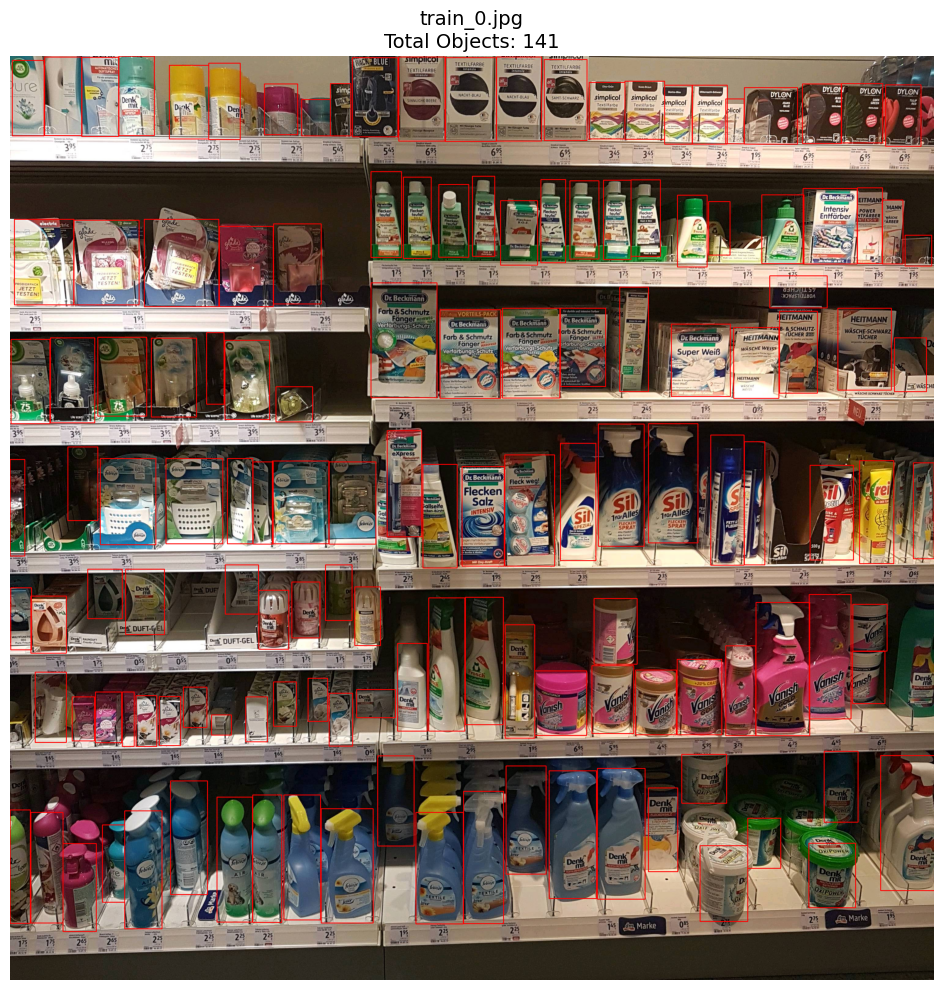

✓ Displayed 141 objects


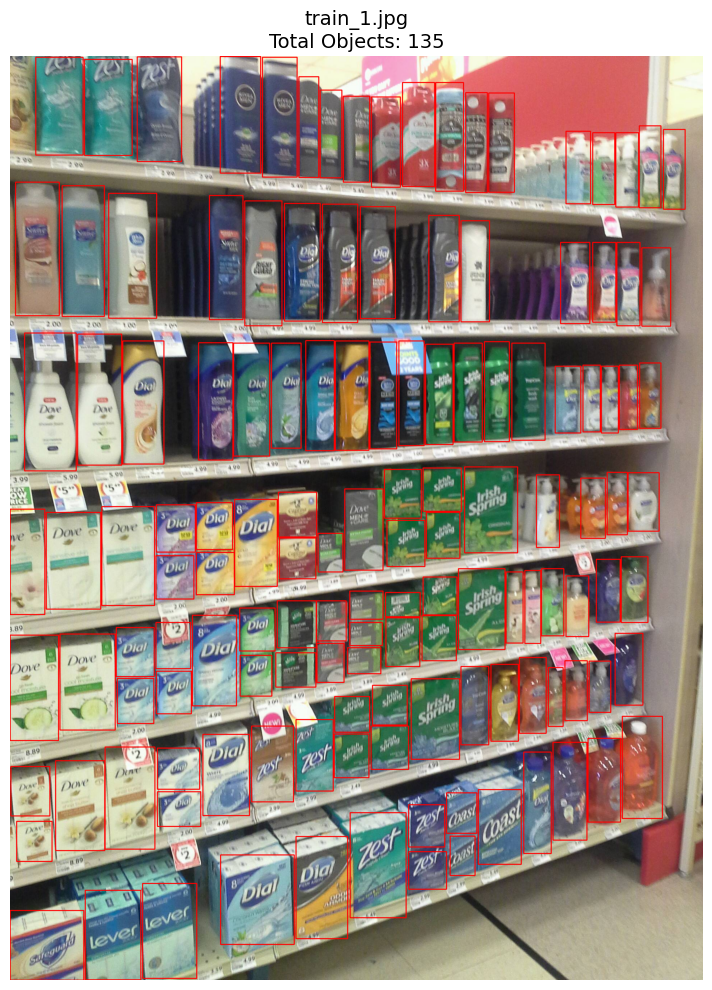

✓ Displayed 135 objects


In [29]:
def visualize_yolo_sample(image_name, split='train'):
    """
    Visualize image with YOLO format labels
    """
    # Load image
    img_path = os.path.join(IMAGES_DIR, split, image_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_h, img_w = img.shape[:2]
    
    # Load labels
    label_name = image_name.replace('.jpg', '.txt')
    label_path = os.path.join(YOLO_LABELS_DIR, split, label_name)
    
    # Draw bboxes
    with open(label_path, 'r') as f:
        lines = f.readlines()
    
    for line in lines:
        cls, x_c, y_c, w, h = map(float, line.strip().split())
        
        # Convert back to pixel coordinates
        x_c *= img_w
        y_c *= img_h
        w *= img_w
        h *= img_h
        
        x1 = int(x_c - w/2)
        y1 = int(y_c - h/2)
        x2 = int(x_c + w/2)
        y2 = int(y_c + h/2)
        
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
    
    # Plot
    plt.figure(figsize=(15, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'{image_name}\nTotal Objects: {len(lines)}', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Displayed {len(lines)} objects")

# Visualize random sample
sample_images = train_df['image_name'].unique()[:5]
for img_name in sample_images[:2]:  # Show 2 samples
    visualize_yolo_sample(img_name, 'train')

## 10. Summary & Next Steps

In [30]:
print("="*70)
print("✅ PREPROCESSING COMPLETE!")
print("="*70)

print(f"\n📊 Summary:")
print(f"  • YOLO labels created: {train_count + val_count + test_count} files")
print(f"  • Config file: {yaml_path}")
print(f"  • Format validated: ✓")

print(f"\n📁 Directory Structure:")
print(f"""
data/
├── images/
│   ├── train/     ({train_count} images)
│   ├── val/       ({val_count} images)
│   └── test/      ({test_count} images)
├── labels/  [NEW]
│   ├── train/     ({train_count} .txt files)
│   ├── val/       ({val_count} .txt files)
│   └── test/      ({test_count} .txt files)
├── annotations/
│   ├── annotations_train.csv
│   ├── annotations_val.csv
│   └── annotations_test.csv
└── data.yaml      [NEW]
""")

print(f"\n🎯 Next Steps:")
print(f"  1. Install YOLOv8: pip install ultralytics")
print(f"  2. Open notebook: 03_yolov8_training.ipynb")
print(f"  3. Start training!")

print("\n" + "="*70)

✅ PREPROCESSING COMPLETE!

📊 Summary:
  • YOLO labels created: 11743 files
  • Config file: ./data\data.yaml
  • Format validated: ✓

📁 Directory Structure:

data/
├── images/
│   ├── train/     (8219 images)
│   ├── val/       (588 images)
│   └── test/      (2936 images)
├── labels/  [NEW]
│   ├── train/     (8219 .txt files)
│   ├── val/       (588 .txt files)
│   └── test/      (2936 .txt files)
├── annotations/
│   ├── annotations_train.csv
│   ├── annotations_val.csv
│   └── annotations_test.csv
└── data.yaml      [NEW]


🎯 Next Steps:
  1. Install YOLOv8: pip install ultralytics
  2. Open notebook: 03_yolov8_training.ipynb
  3. Start training!



## ✅ Checklist:

- [ ] Dataset reorganized into train/val/test
- [ ] YOLO labels created
- [ ] data.yaml config created
- [ ] Labels validated
- [ ] Sample visualization checked
- [ ] Ready for training!

---

**Next Notebook:** `03_yolov8_training.ipynb`